# CRM Sales Data Analysis and Insights Using SQLite
### Assignment 3 
### Siddharthan Muthukumaran - 25007430

## Database Schema Design

All information related to the CRM sales pipeline—including accounts, products, sales agents, deal performance, public interest trends, and conversion outcomes—is carefully structured and analyzed in this database. The schema has been designed following Third Normal Form (3NF) principles to reduce redundancy, ensure data integrity, and enhance query performance.

The database consists of six primary relational tables and three analytical views, each carefully crafted to capture insights into sales performance, product effectiveness, and temporal trends. This well-organized structure enables clear, efficient tracking of sales opportunities while supporting deeper insights through external trend integration.

## Tables Overview

The database comprises six core tables, each playing a specific role in modeling the sales process and external data signals:

| Table Name        | Description                                                                 |
|-------------------|-----------------------------------------------------------------------------|
| `accounts`        | Stores company account information, including industry and region details. |
| `sales_agents`    | Contains individual agent profiles responsible for closing opportunities.  |
| `products`        | Lists hardware products and their associated categories.                   |
| `opportunities`   | Tracks each sales opportunity, linking products, accounts, and agents.     |
| `google_trends`   | Time-series data capturing public search interest in relevant keywords.    |
| `merged_insights` | Consolidated dataset combining CRM and external signals for analysis.      |

Each table is linked through **primary and foreign key constraints** to support relational integrity and seamless join operations.


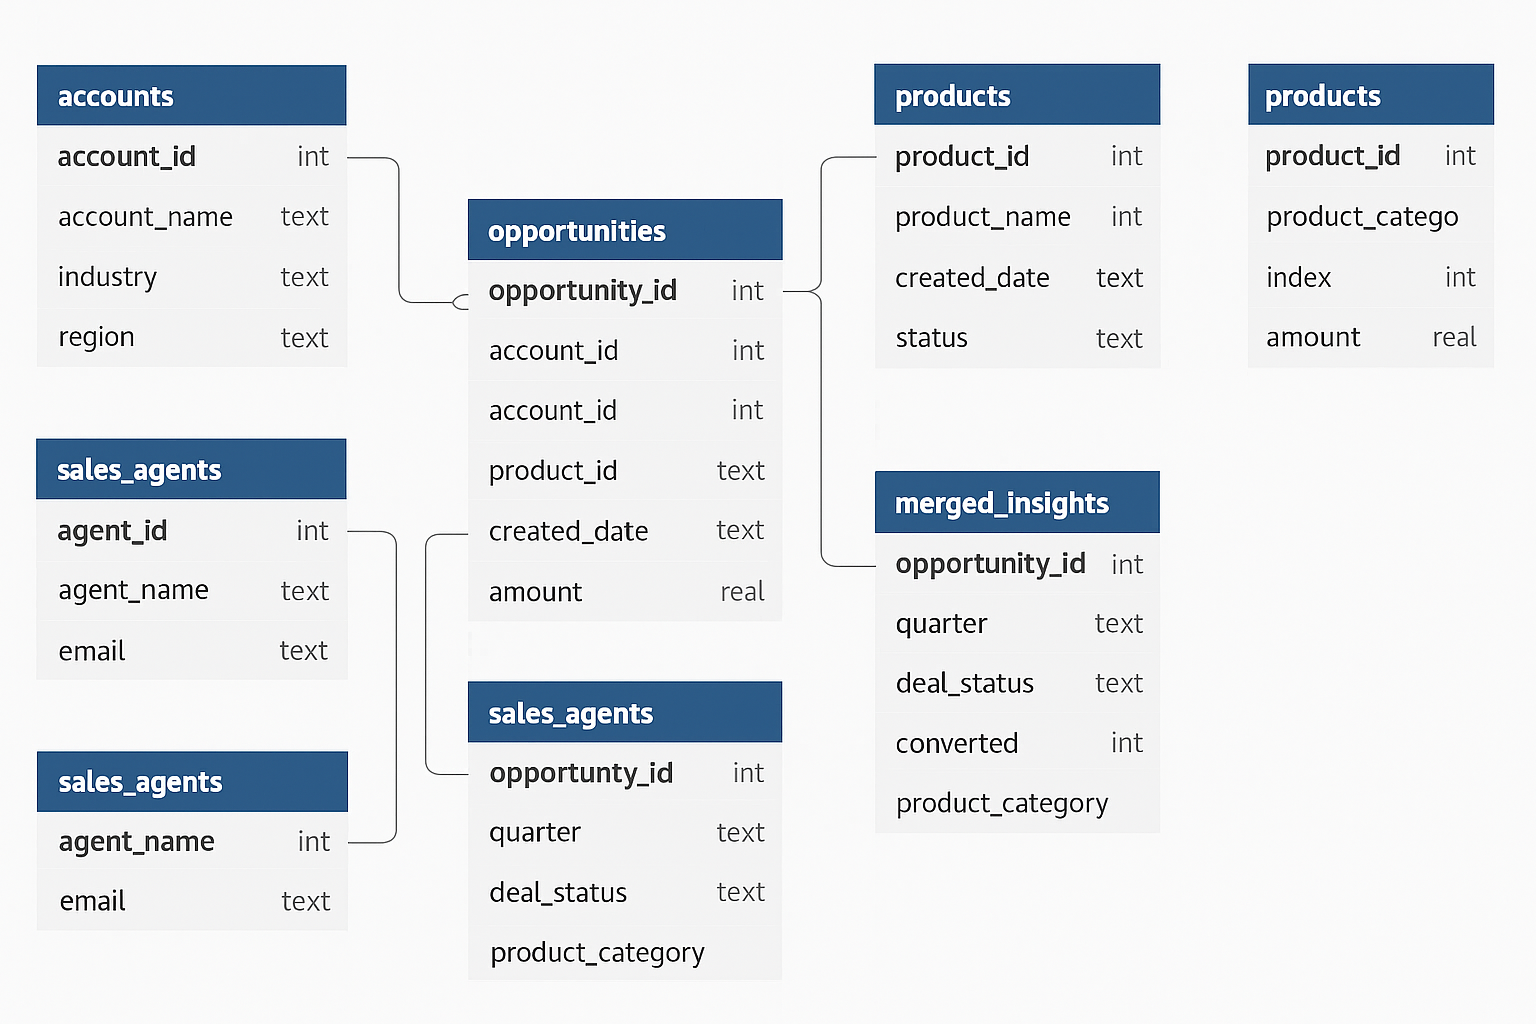

In [261]:
from IPython.display import Image
Image("Assignment 3/sql.png")

### Relationships

Each sales opportunity connects to one product, one account, and one sales agent, forming the core of the sales pipeline.

The `merged_insights` table links back to individual opportunities to track deal conversions and enrich them with external signals.

Google Trends data stands alone but can be aligned by date or keyword for external analysis.

Referential integrity is maintained through foreign key constraints, ensuring consistency across product, account, and agent links.

In [ ]:
import sqlite3
import pandas as pd
import sqlite3
import os


## SQLite Database and Table Creation

In [176]:
# Connect to database
conn = sqlite3.connect("crm_sales.db")
cursor = conn.cursor()

# Drop tables if they already exist (for re-runs during dev)
cursor.executescript("""
DROP TABLE IF EXISTS merged_insights;
DROP TABLE IF EXISTS google_trends;
DROP TABLE IF EXISTS opportunities;
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS sales_agents;
DROP TABLE IF EXISTS accounts;
""")

# Create tables
cursor.execute("""
CREATE TABLE accounts (
    account_id INTEGER PRIMARY KEY,
    account_name TEXT,
    industry TEXT,
    region TEXT
);
""")

cursor.execute("""
CREATE TABLE sales_agents (
    agent_id INTEGER PRIMARY KEY,
    agent_name TEXT,
    email TEXT
);
""")

cursor.execute("""
CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT,
    product_category TEXT
);
""")

cursor.execute("""
CREATE TABLE opportunities (
    opportunity_id INTEGER PRIMARY KEY,
    account_id INTEGER,
    agent_id INTEGER,
    product_id INTEGER,
    created_date TEXT,
    status TEXT,
    amount REAL,
    FOREIGN KEY (account_id) REFERENCES accounts(account_id),
    FOREIGN KEY (agent_id) REFERENCES sales_agents(agent_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id)
);
""")

cursor.execute("""
CREATE TABLE google_trends (
    date TEXT,
    keyword TEXT,
    interest INTEGER,
    PRIMARY KEY (date, keyword)
);
""")

cursor.execute("""
CREATE TABLE merged_insights (
    opportunity_id INTEGER,
    date TEXT,
    city TEXT,
    interest INTEGER,
    aircraft_activity INTEGER,
    passenger_trips INTEGER,
    load_factor REAL,
    seat_allocation INTEGER,
    FOREIGN KEY (opportunity_id) REFERENCES opportunities(opportunity_id)
);
""")

# Commit and close
conn.commit()
conn.close()


#### In this step, we define the core structure of our relational database, crm_sales.db, using SQLite.

Six tables are created:

1. accounts: Stores company account info
2. sales_agents: Contains sales team member details
3. products: Lists product information
4. opportunities: Tracks sales pipeline records (with links to accounts, agents, and products)
5. google_trends: Holds time-series public search interest for keywords
6. merged_insights: Pre-joined data for analysis, linking product and conversion data with external signals
   
Each table includes primary keys and foreign key constraints where appropriate to maintain relational integrity.

Before creation, any existing versions of the tables are dropped to ensure the notebook is re-runnable for testing and iteration.

## Step 2: Data Loading, Cleaning, and Insertion into SQLite

In [178]:

# LOAD CSV FILES
df_accounts = pd.read_csv("Assignment 3/Datasets used/accounts.csv")
df_agents = pd.read_csv("Assignment 3/Datasets used/Sales_Agents.csv")
df_products = pd.read_csv("Assignment 3/Datasets used/products.csv")
df_opportunities = pd.read_csv("Assignment 3/Datasets used/Opportunities.csv")
df_trends = pd.read_csv("Assignment 3/Datasets used/google_trends.csv")
df_merged = pd.read_csv("Assignment 3/Datasets used/merged_insights.csv")

# RENAME & REFORMAT

# ACCOUNTS
df_accounts.rename(columns={
    'account': 'account_name',
    'sector': 'industry',
    'office_location': 'region'
}, inplace=True)
df_accounts.insert(0, 'account_id', range(1, 1 + len(df_accounts)))
df_accounts = df_accounts[['account_id', 'account_name', 'industry', 'region']]

# SALES_AGENTS
df_agents.rename(columns={
    'sales_agent': 'agent_name',
    'manager': 'email'
}, inplace=True)
df_agents.insert(0, 'agent_id', range(1, 1 + len(df_agents)))
df_agents = df_agents[['agent_id', 'agent_name', 'email']]

# PRODUCTS
df_products.rename(columns={
    'product': 'product_name',
    'series': 'product_category'
}, inplace=True)
df_products.insert(0, 'product_id', range(1, 1 + len(df_products)))
df_products = df_products[['product_id', 'product_name', 'product_category']]

# OPPORTUNITIES
df_opportunities.rename(columns={
    'sales_agent': 'agent_id',
    'product': 'product_id',
    'account': 'account_id',
    'engage_date': 'created_date',
    'deal_stage': 'status',
    'close_value': 'amount'
}, inplace=True)
df_opportunities = df_opportunities[['opportunity_id', 'account_id', 'agent_id', 'product_id', 'created_date', 'status', 'amount']]

# GOOGLE_TRENDS (wide → long)
trend_cols = ['GTXPro', 'sales software', 'buy computer', 'B2B deals']
df_trends = df_trends.melt(id_vars='date', value_vars=trend_cols,
                           var_name='keyword', value_name='interest')
df_trends.dropna(subset=['interest'], inplace=True)
df_trends = df_trends[['date', 'keyword', 'interest']]

# MERGED_INSIGHTS
df_merged = df_merged[['opportunity_id', 'quarter', 'deal_status', 'converted', 'product_category']]


#  INSERT TO SQLITE
conn = sqlite3.connect("crm_sales.db")

df_accounts.to_sql("accounts", conn, if_exists="replace", index=False)
df_agents.to_sql("sales_agents", conn, if_exists="replace", index=False)
df_products.to_sql("products", conn, if_exists="replace", index=False)
df_opportunities.to_sql("opportunities", conn, if_exists="replace", index=False)
df_trends.to_sql("google_trends", conn, if_exists="replace", index=False)
df_merged.to_sql("merged_insights", conn, if_exists="replace", index=False)

# VERIFY INSERTS

print("Table row counts:")
print(pd.read_sql("SELECT COUNT(*) AS accounts_count FROM accounts", conn))
print(pd.read_sql("SELECT COUNT(*) AS agents_count FROM sales_agents", conn))
print(pd.read_sql("SELECT COUNT(*) AS products_count FROM products", conn))
print(pd.read_sql("SELECT COUNT(*) AS opps_count FROM opportunities", conn))
print(pd.read_sql("SELECT COUNT(*) AS trends_count FROM google_trends", conn))
print(pd.read_sql("SELECT COUNT(*) AS merged_count FROM merged_insights", conn))

conn.close()


✅ Table row counts:
   accounts_count
0              85
   agents_count
0            35
   products_count
0               7
   opps_count
0        8800
   trends_count
0          1048
   merged_count
0          8800


#### Key actions performed:
- **Renamed columns** to match table schema (e.g., `account` → `account_name`, `sales_agent` → `agent_name`)
- **Added unique IDs** using `range()` where needed (e.g., `account_id`, `agent_id`, `product_id`)
- **Reshaped** the `google_trends` dataset from wide to long format using `melt()`
- **Filtered out missing interest values** in trend data
- **Selected only relevant columns** from `merged_insights`

## SQL Queries - Exploring CRM Datasets

In [181]:

conn = sqlite3.connect("crm_sales.db")


In [182]:
# Query 1: List all opportunities with basic info

query1 = """
SELECT opportunity_id, account_id, agent_id, product_id, created_date, status, amount
FROM opportunities
LIMIT 10;
"""
pd.read_sql(query1, conn)


,opportunity_id,account_id,agent_id,product_id,created_date,status,amount
0,1C1I7A6R,Cancity,Moses Frase,GTX Plus Basic,2016-10-20,Won,1054.0
1,Z063OYW0,Isdom,Darcel Schlecht,GTXPro,2016-10-25,Won,4514.0
2,EC4QE1BX,Cancity,Darcel Schlecht,MG Special,2016-10-25,Won,50.0
3,MV1LWRNH,Codehow,Moses Frase,GTX Basic,2016-10-25,Won,588.0
4,PE84CX4O,Hatfan,Zane Levy,GTX Basic,2016-10-25,Won,517.0
5,ZNBS69V1,Ron-tech,Anna Snelling,MG Special,2016-10-29,Won,49.0
6,9ME3374G,J-Texon,Vicki Laflamme,MG Special,2016-10-30,Won,57.0
7,7GN8Q4LL,Cheers,Markita Hansen,GTX Basic,2016-11-01,Won,601.0
8,OLK9LKZB,Zumgoity,Niesha Huffines,GTX Plus Basic,2016-11-01,Won,1026.0
9,HAXMC4IX,None,James Ascencio,MG Advanced,2016-11-03,Engaging,NaN


This query retrieves the records from the `opportunities` table, showing basic sales deal attributes including:

- Opportunity ID  
- Associated account, agent, and product IDs  
- Deal creation date  
- Deal status  
- Deal amount

In [184]:
#Query 2: Show Opportunity-Level Insights from

query2 = """
SELECT opportunity_id, product_category, deal_status, converted, quarter
FROM merged_insights
LIMIT 10;
"""
pd.read_sql(query2, conn)


,opportunity_id,product_category,deal_status,converted,quarter
0,1C1I7A6R,GPU,Closed,1,2016Q4
1,Z063OYW0,GPU,Closed,1,2016Q4
2,EC4QE1BX,Printer,Closed,1,2016Q4
3,MV1LWRNH,GPU,Closed,1,2016Q4
4,PE84CX4O,GPU,Closed,1,2016Q4
5,ZNBS69V1,Printer,Closed,1,2016Q4
6,9ME3374G,Printer,Closed,1,2016Q4
7,7GN8Q4LL,GPU,Closed,1,2016Q4
8,OLK9LKZB,GPU,Closed,1,2016Q4
9,HAXMC4IX,Printer,Ongoing,0,2016Q4


This query retrieves the records from the `merged_insights` table, showing simplified sales opportunity details including:

- Opportunity ID  
- Product category  
- Deal status  
- Whether the opportunity was converted  
- The quarter in which the deal occurred

In [186]:
#Query 3: Total Converted Deals by Product Category

query3 = """
SELECT product_category, COUNT(*) AS converted_deals
FROM merged_insights
WHERE converted = 1
GROUP BY product_category
ORDER BY converted_deals DESC;
"""
pd.read_sql(query3, conn)


,product_category,converted_deals
0,GPU,2776
1,Printer,1462


This query identifies the number of successfully converted sales opportunities per product category. It filters only the converted deals and aggregates the count:

- Filters rows where `converted = 1` (i.e., successful conversions)  
- Groups them by `product_category`  
- Orders the results in descending order of converted deal count

In [188]:
# Query 4: High-value deals (> $10,000)

query4 = """
SELECT opportunity_id, amount, status
FROM opportunities
WHERE amount > 10000
ORDER BY amount DESC
LIMIT 10;
"""
pd.read_sql(query4, conn)


,opportunity_id,amount,status
0,60UOBOEM,30288.0,Won
1,4V0S4BA3,29617.0,Won
2,GB6C2UK5,29220.0,Won
3,LSJ2A8ZX,29166.0,Won
4,H3K2E35I,27971.0,Won
5,731TOWDY,27385.0,Won
6,1H2PVLZ3,26186.0,Won
7,XUSUEAV7,25897.0,Won
8,4X3H9YD5,25791.0,Won
9,6X4EEUGA,25464.0,Won


This query retrieves the top 10 high-value sales deals from the `opportunities` table:

- Filters opportunities where the `amount` exceeds $10,000  
- Selects the `opportunity_id`, `amount`, and `status`  
- Orders the deals in descending order of deal value  
- Limits the output to the top 10 highest-value opportunities


In [190]:
# Query 5: Google Trends interest for 'GTXPro' over time

query5 = """
SELECT date, interest
FROM google_trends
WHERE keyword = 'GTXPro'
ORDER BY date;
"""
pd.read_sql(query5, conn)


,date,interest
0,2020-05-24,0
1,2020-05-31,0
2,2020-06-07,0
3,2020-06-14,0
4,2020-06-21,0
...,...,...
257,2025-04-27,0
258,2025-05-04,0
259,2025-05-11,0
260,2025-05-18,0


This query tracks public interest in the product **GTXPro** over time using Google Trends data:

- Filters rows in the `google_trends` table where `keyword` is 'GTXPro'  
- Selects the `date` and corresponding `interest` score  
- Orders the results chronologically to visualize trend progression over time


In [192]:
query6 = """
SELECT 
    product_category,
    COUNT(*) AS total_opportunities,
    SUM(CASE WHEN converted = 1 THEN 1 ELSE 0 END) AS converted_count,
    ROUND(1.0 * SUM(CASE WHEN converted = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS conversion_rate
FROM merged_insights
GROUP BY product_category
ORDER BY conversion_rate DESC;
"""
pd.read_sql(query6, conn)


,product_category,total_opportunities,converted_count,conversion_rate
0,GPU,5697,2776,0.49
1,Printer,3103,1462,0.47


This query evaluates the **conversion performance by product category** from the `merged_insights` table. It provides:

- `product_category`: The category of the product
- `total_opportunities`: Total number of sales opportunities for each category
- `converted_count`: How many of those opportunities resulted in a conversion (i.e., successful deals)
- `conversion_rate`: Conversion success as a percentage, rounded to two decimal places

The results are **sorted by conversion rate in descending order**, helping identify which product categories are the most effective in closing deals.


### Summary - SQL Queries

In this section, we explored key business insights from the CRM database using structured SQL queries. The queries were crafted to uncover both operational and strategic information relevant to product performance, sales funnel health, and market interest.

#### Key objectives included:

1. Retrieving basic opportunity-level deal information
2. Analyzing conversion trends by product category
3. Highlighting high-value deals and conversion efficiency
4. Leveraging Google Trends data to understand public interest over time.
5. Calculating conversion rates and building views for ongoing performance tracking

Together, these queries laid the foundation for deeper analysis and provided actionable insights for stakeholders to optimize sales, marketing, and resource planning strategies

## VIEW

In [195]:
# Drop the broken view first
conn.execute("DROP VIEW IF EXISTS opportunity_details_view")

# Recreate with reliable columns
conn.execute("""
CREATE VIEW opportunity_details_view AS
SELECT 
    opportunity_id,
    product_category,
    deal_status AS status,
    converted,
    quarter
FROM merged_insights
""")


This view is created to simplify access to high-level opportunity insights by extracting selected fields from the `merged_insights` table. Specifically, it includes:

- `opportunity_id`: Unique identifier for each sales opportunity  
- `product_category`: The category of the product involved  
- `deal_status`: Renamed to `status` for clarity  
- `converted`: Indicates if the opportunity was successfully closed  
- `quarter`: The time period in which the deal was active

The view helps streamline queries for conversion analysis or quarterly trends without needing to repeatedly join or filter large datasets.

In [197]:
#conversion_summary_view
view2 = """
CREATE VIEW IF NOT EXISTS conversion_summary_view AS
SELECT 
    product_category,
    COUNT(*) AS total_opportunities,
    SUM(CASE WHEN converted = 1 THEN 1 ELSE 0 END) AS converted_count,
    ROUND(1.0 * SUM(CASE WHEN converted = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS conversion_rate
FROM merged_insights
GROUP BY product_category;
"""
conn.execute(view2)


This view provides a summarized snapshot of conversion performance by product category. It calculates:

- `product_category`: Grouping key for analysis  
- `total_opportunities`: Number of opportunities available for each product category  
- `converted_count`: Number of deals successfully converted  
- `conversion_rate`: Proportion of successful deals (converted / total), rounded to two decimal places

This view is useful for evaluating which product categories are most effective at closing deals and identifying high-performing or underperforming segments in the pipeline.

In [199]:
#quarterly_conversion_trends
view3 = """
CREATE VIEW IF NOT EXISTS quarterly_conversion_trends AS
SELECT 
    quarter,
    COUNT(*) AS total_opportunities,
    SUM(CASE WHEN converted = 1 THEN 1 ELSE 0 END) AS converted_count,
    ROUND(1.0 * SUM(CASE WHEN converted = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS conversion_rate
FROM merged_insights
GROUP BY quarter
ORDER BY quarter;
"""
conn.execute(view3)


This view analyzes conversion performance over time by quarter. It includes:

- `quarter`: Time period indicator (e.g., Q1, Q2, etc.)  
- `total_opportunities`: Total number of deals considered per quarter  
- `converted_count`: Number of deals that were successfully converted in that quarter  
- `conversion_rate`: Conversion efficiency for the quarter (converted / total), rounded to two decimal places

This view helps identify seasonal or time-based patterns in deal success, supporting more informed decisions around sales planning and resource allocation.

## Read Views


In [202]:
pd.read_sql("SELECT * FROM opportunity_details_view LIMIT 5;", conn)


,opportunity_id,product_category,status,converted,quarter
0,1C1I7A6R,GPU,Closed,1,2016Q4
1,Z063OYW0,GPU,Closed,1,2016Q4
2,EC4QE1BX,Printer,Closed,1,2016Q4
3,MV1LWRNH,GPU,Closed,1,2016Q4
4,PE84CX4O,GPU,Closed,1,2016Q4


In [203]:
pd.read_sql("SELECT * FROM conversion_summary_view;", conn)

,product_category,total_opportunities,converted_count,conversion_rate
0,GPU,5697,2776,0.49
1,Printer,3103,1462,0.47


In [204]:
pd.read_sql("SELECT * FROM quarterly_conversion_trends;", conn)

,quarter,total_opportunities,converted_count,conversion_rate
0,None,500,0,0.00
1,2016Q4,358,250,0.70
2,2017Q1,1619,898,0.55
3,2017Q2,2388,1246,0.52
4,2017Q3,2770,1207,0.44
5,2017Q4,1165,637,0.55


In [205]:
pd.read_sql("SELECT * FROM conversion_summary_view;", conn)

,product_category,total_opportunities,converted_count,conversion_rate
0,GPU,5697,2776,0.49
1,Printer,3103,1462,0.47


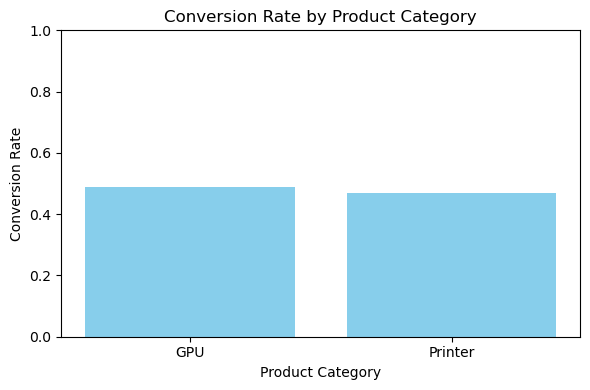

In [206]:
import matplotlib.pyplot as plt

df = pd.read_sql("SELECT * FROM conversion_summary_view;", conn)

plt.figure(figsize=(6, 4))
plt.bar(df['product_category'], df['conversion_rate'], color='skyblue')
plt.title("Conversion Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Conversion Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### Visualization: Conversion Rate by Product Category

This bar chart compares the conversion rates of different product categories using data from the `conversion_summary_view`.

- **GPU** and **Printer** categories have similar conversion performance, with GPUs slightly leading at ~49%.  
- The Y-axis is scaled between 0 and 1 to reflect the percentage as a decimal value.

This visualization helps quickly identify which product lines are performing better in closing deals and may guide where to focus marketing or sales optimization efforts.


### Summary of views

To simplify repetitive analysis and improve readability, we created three SQL views:

- `opportunity_details_view`: Cleaned and filtered deal-level information  
- `conversion_summary_view`: Product-level conversion performance  
- `quarterly_conversion_trends`: Time-based conversion insights

These views support targeted queries and make analysis modular, reusable, and scalable.

## Conclusion

This project used SQLite to create a relational CRM sales database, integrating internal and external datasets. Through SQL queries and views, we gained valuable insights such as:

Top-performing product categories by conversion rate

High-value deals worth over $10,000

Temporal trends in conversions across quarters

Public interest data (via Google Trends) to enrich CRM insights

Visualizing conversion performance helped surface actionable insights for marketing and sales strategy. SQL views streamlined repeatable analysis and highlighted modular patterns across the sales pipeline.

The project demonstrated how structured databases, paired with SQL and pandas, can turn raw operational data into business intelligence.